In [23]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 0. Lectura de los df

Leemos los df del fichero `pickle` y lo cargamos en una variable `df` que será un pandas.Dataframe.

En nuestro caso como nuestros NIA´s acaban en 78 y 48 cargamos el fichero 26

$48 + 78 \pmod {100} = 26$ 

In [24]:
# Abre el archivo en modo lectura binaria ('rb')
with open('../data/bank_26.pkl', 'rb') as archivo:
    df = pickle.load(archivo)

/tmp/ipykernel_5817/3242033964.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(archivo)


### 1. Características Básicas de nuestro Dataset

En primer lugar, nuestro dataset contiene **11000** entradas (filas) y **17** atributos (columnas)

En esta salida también se puede observar el tipo de cada variable. Así pues, podemos concluir que:

| Variables Numéricas | Variables Categóricas |
|---------------------|-----------------------|
| age | job |
| balance | marital |
| day | education |
| duration| default |
| campaign| housing |
| pdays | loan |
| previous| contact |
|| month |
|| poutcome |
|| **deposit** |

Donde `deposit` es la variable a predecir, recordar que este problema es de **Clasificación binaria**, dado un cliente ¿contratará un Déposito (Si/No)?

Sin embargo, a partir de esta salida no podemos identificar las variables ordinales por lo que abrá que mirar con 'lupa' las variables categóricas para separarlas.

In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 11000 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11000 non-null  int64 
 1   job        11000 non-null  object
 2   marital    10601 non-null  object
 3   education  11000 non-null  object
 4   default    11000 non-null  object
 5   balance    11000 non-null  int64 
 6   housing    11000 non-null  object
 7   loan       11000 non-null  object
 8   contact    11000 non-null  object
 9   day        11000 non-null  int64 
 10  month      11000 non-null  object
 11  duration   11000 non-null  int64 
 12  campaign   11000 non-null  int64 
 13  pdays      11000 non-null  int64 
 14  previous   11000 non-null  int64 
 15  poutcome   11000 non-null  object
 16  deposit    11000 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.5+ MB


#### ¿Cuáles de las variables categóricas anteriores son Ordinales?

Para contestar esta pregunta tendremos que ver valores que pueden tomar todas las features y analizar si algunos siguen una lógica de orden.

Existen dos variables susceptibles de ser consideradas ordinales `education` y `month`.

Cabe señalar que si se deseara hacer ordinal `education` habría que gestionar los valores 'unknown' de alguna forma porque sino no se estaría respetando la idea de orden.

In [26]:
for categorical in df.select_dtypes(exclude="number"):
    print(f"{categorical}: {df[categorical].unique()}\n")

job: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']

marital: ['married' None 'divorced' 'single']

education: ['secondary' 'tertiary' 'primary' 'unknown']

default: ['no' 'yes']

housing: ['yes' 'no']

loan: ['no' 'yes']

contact: ['unknown' 'cellular' 'telephone']

month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

poutcome: ['unknown' 'other' 'failure' 'success']

deposit: ['yes' 'no']



#### ¿Qué variables Categóricas cuentan con una alta cardinalidad?

Como se puede apreciar en la siguiente salida, los atributos `job` y `month` tienen una alta cardinalidad, tienen 12 valores posibles. Esto puede ser objeto de preprocesado y de realizar Feature Engineering.

In [27]:
df.select_dtypes(exclude='number').nunique()

job          12
marital       3
education     4
default       2
housing       2
loan          2
contact       3
month        12
poutcome      4
deposit       2
dtype: int64

Otra manera de verlo, es con esta métrica que recoge la proporción de valores únicos por columna entre el número total de filas.

In [28]:
df.select_dtypes(exclude='number').nunique() / df.shape[0] * 100

job          0.109091
marital      0.027273
education    0.036364
default      0.018182
housing      0.018182
loan         0.018182
contact      0.027273
month        0.109091
poutcome     0.036364
deposit      0.018182
dtype: float64

#### ¿El Dataset está desbalanceado?

Ahora, vamos a comprobar si el dataset está desbalanceado.

Como se puede observar en la siguiente salida el 47.45% de las entradas han sido clientes que **NO** han contratado un déposito mientras que el 52,55% han sido clientes que **SÍ** lo han hecho. 

Por lo tanto, parece haber un ligero desbalanceo, aunque en la fase de entrenamiento habrá que entrenar usando diferentes métricas (**Accuracy**, **Precision**, **Recall** y **F1-Score**) para comprobar que métrica nos reporta el mejor rendimiento.

En este caso, un Falso Positivo consiste en un cliente que no está dispuesto a contratar un depósito pero nuestro modelo considera que si por lo que se le aplicará una estrategia de promoción en vano.

Mientras, que un Falso Negativo consiste en un cliente que sí está dispuesto a contratar un depósito pero nuestro modelo considera que no por lo que no se le aplicará la estrategia de promoción más adecuada.

De este modo, desde la óptica de negocio de este problema parece que es más importante minimizar los Falsos Negativos considerando que no existen más costes asociados a cometer Falsos Positivos.

Esto quiere decir, que de las métricas mencionadas anteriormente podemos prescindir de **Precision** que es la que refleja los Falsos Positivos.

In [29]:
print(df['deposit'].value_counts())
print(f"\nClase YES: {round(len(df[df['deposit'] == 'yes'])/len(df)*100, 2)}%\nClase NO: {round(len(df[df['deposit'] == 'no'])/len(df)*100, 2)}%")

deposit
no     5780
yes    5220
Name: count, dtype: int64

Clase YES: 47.45%
Clase NO: 52.55%


#### Missing Values 

A continuación, se muestran los valores nulos que contiene nuestro dataset.

Solo existe un atributo que contiene valores nulos que es `marital`, un 3.63% de sus valores son nulos, por tanto habrá que tratarlo más adelante.

In [30]:
print(df.isnull().sum())
print(f"\n% de Valores Nulos del Atributo Marital: {round(df['marital'].isnull().sum()/len(df['marital']) * 100, 2)}%")

age            0
job            0
marital      399
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day            0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
deposit        0
dtype: int64

% de Valores Nulos del Atributo Marital: 3.63%


### 2. Análisis Univariante

En este apartado se realizará un análisis univariante de algunos atributos del dataset.

#### Pdays

Pdays es un atributo del dataset que refleja el número de días desde que este cliente fué contactacto en la campaña anterior. Si es -1 significa que no ha habido contacto o es desconocido.

La distribución de valores de este atributo es muy asimétrica un 74.57% de valores son -1, es decir, que el contacto es desconocido. Esto es muy problemático ya que este valor elimina el sentido de orden numérico que tienen el resto de valores por lo que habrá que preprocesarla de alguna forma para eliminar este problema

In [31]:
print(df['pdays'].value_counts())
print(f"\n% de Pdays == -1: {round(len(df[df['pdays'] == -1])/len(df)*100,2)}%")

pdays
-1      8203
 92      105
 182      88
 91       82
 181      79
        ... 
 651       1
 214       1
 24        1
 701       1
 118       1
Name: count, Length: 472, dtype: int64

% de Pdays == -1: 74.57%


Text(0.5, 1.0, 'Distribución en Bruto de Pdays')

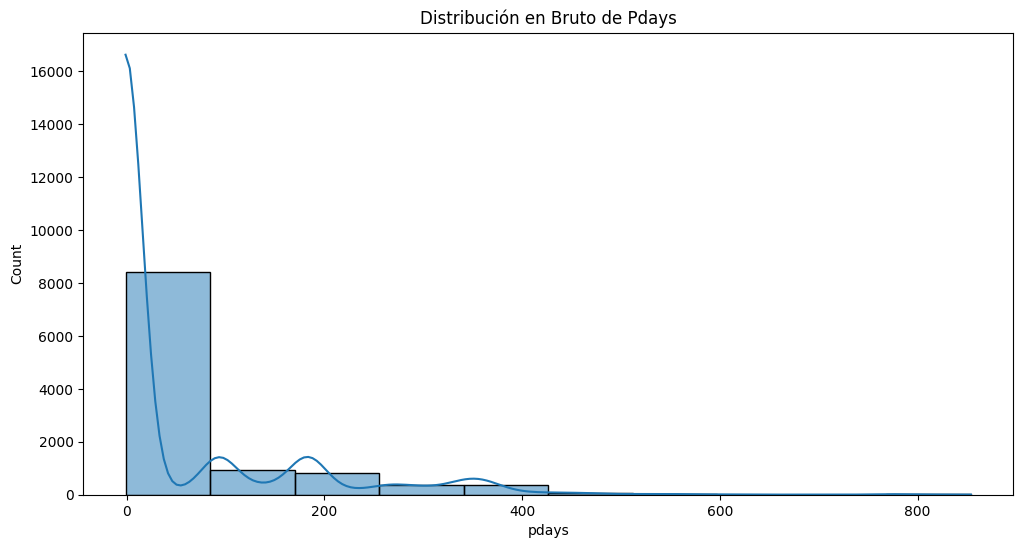

In [32]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df,
    x='pdays',
    bins=10,
    kde=True
)
plt.title("Distribución en Bruto de Pdays")

#### Variables Numéricas

+ **age**: La mediana de edad se encuentra entorno a los 40 años, además la distribución parece exhibir una asimetría positiva.

+ **balance**: La mediana de Balance se encuentra por debajo de 2000, además exhibe una considerable asimetría positiva, de hecho su distribución se asemeja bastante a una distribución de potencias.

+ **day**: Este atributo exhibe una distribución multimodal. Además, el valor mediano de días desde el último contacto es 15.

+ **duration**: Este atributo también presenta una asimetría positiva, la mediana parece ser de 250, es decir, que la mediana del tiempo del último contacto es de 250 segundos.

+ **campaign** y **previous**: Estas variables exhiben una fuerte asimetría, sus distribuciones se asemejan a distribuciones de potencia y tienen valores muy atípicos. El valor máximo de campaign es 63, es decir, que el máximo número de contactos que ha habido durante esta campaña para ese cliente ha sido de 63. El valor máximo de previous es 58, es decir, hay un cliente que fue contactado 58 veces antes de esta campaña.

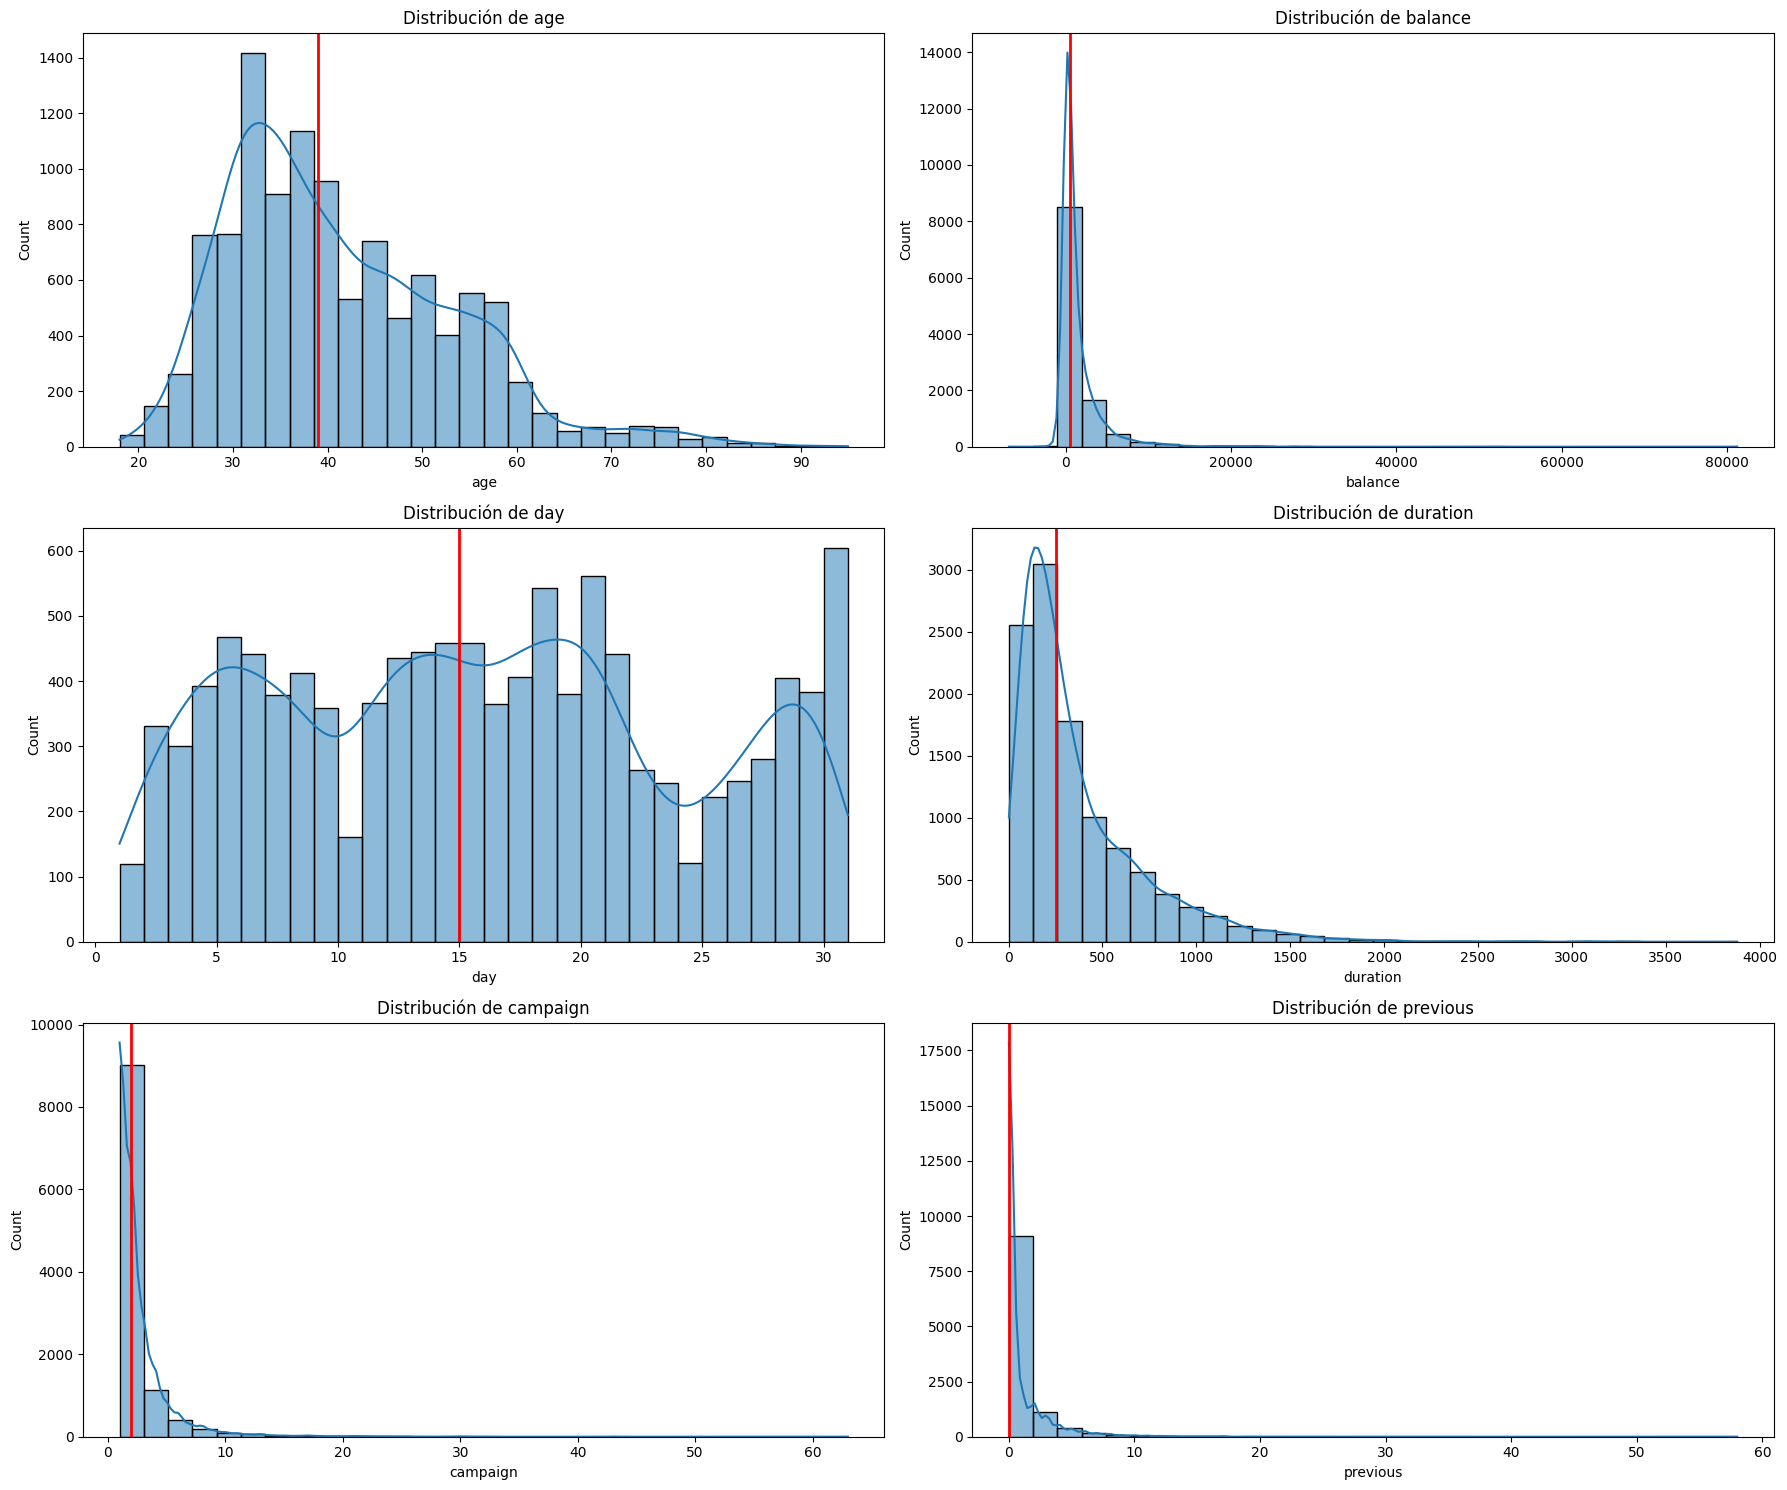

In [33]:
# Creo una lista con las variables numéricas
df_numerical = df.select_dtypes(include="int64").columns

# Elimino pdays que ya ha sido analizada
df_numerical = df_numerical.drop('pdays')

n_cols = 2
n_rows = int(np.ceil(len(df_numerical)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten() # Convertimos la matriz 2D a un array para poder iterarlo

for i, num in enumerate(df_numerical):
    sns.histplot(
        data=df,
        x=num,
        ax=axes[i],
        kde=True,
        bins=30
    )
    axes[i].axvline(
        x=df[num].median(),
        color='red',
        linewidth=2.0
    )
    axes[i].set_title(f"Distribución de {num}")

plt.tight_layout()

In [34]:
print(f"Valor máximo de campaign {df['campaign'].max()}")
print(f"Valor máximo de previous {df['previous'].max()}")

Valor máximo de campaign 63
Valor máximo de previous 58


#### Job

Las tres categorías de empleos más comunes son: **Management**, **Blue-Collar** y **Technician**

Text(0.5, 1.0, 'Distribución de Job')

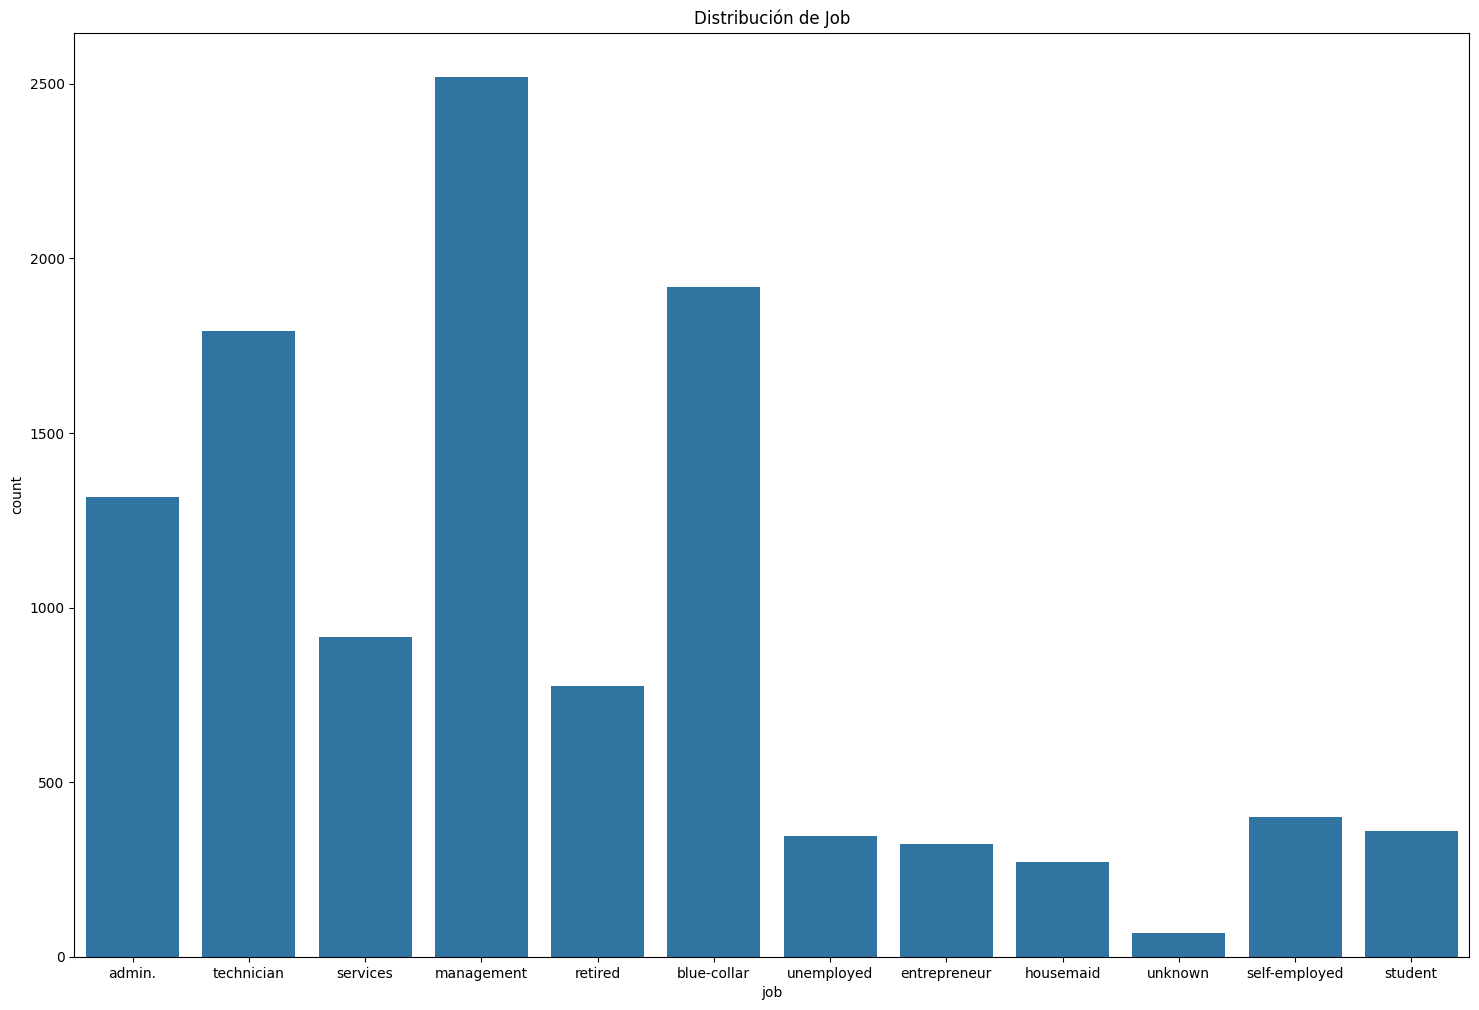

In [35]:
plt.figure(figsize=(18, 12))
sns.countplot(
    data=df,
    x='job'
)
plt.title("Distribución de Job")

#### Variables Categóricas

+ **marital**: La distribución no exhibe a priori nada llamativa como por ejemplo que la clase mayoritaria fuera *divorced*.

+ **education**: La distribución no exhibe a priori nada llamativo como por ejemplo que la clase mayoritaria fuera *primary*, es decir, que la mayoría de las entradas hubieran terminado de estudiar a los 12 años.

+ **default**: La gran mayoría han devuelto sus créditos y existen unas pocas entradas que no lo han hecho, en el siguiente apartado analizaremos si estos siguen luego un patrón de contratar un depósito o no.

+ **housing**: La distribución es muy pareja entre los que tienen y no tienen hipoteca

+ **loan**: La mayoría no tienen un préstamo.

+ **contact**: La mayoría fueron contactados a través del teléfono móvil.

+ **month**: Para la mayoría el último mes de contacto fue en mayo.

+ **poutcome**: Este atributo presenta una problemática ya que para la mayoría de entradas el resultado de la campaña anterior es desconocido, además, la diferencia entre 'desconocido' y 'otro' parece ambigua. Puede ser buena idea crear dos variables binarias nuevas: 'PrevSucess' y 'PrevFailure'.

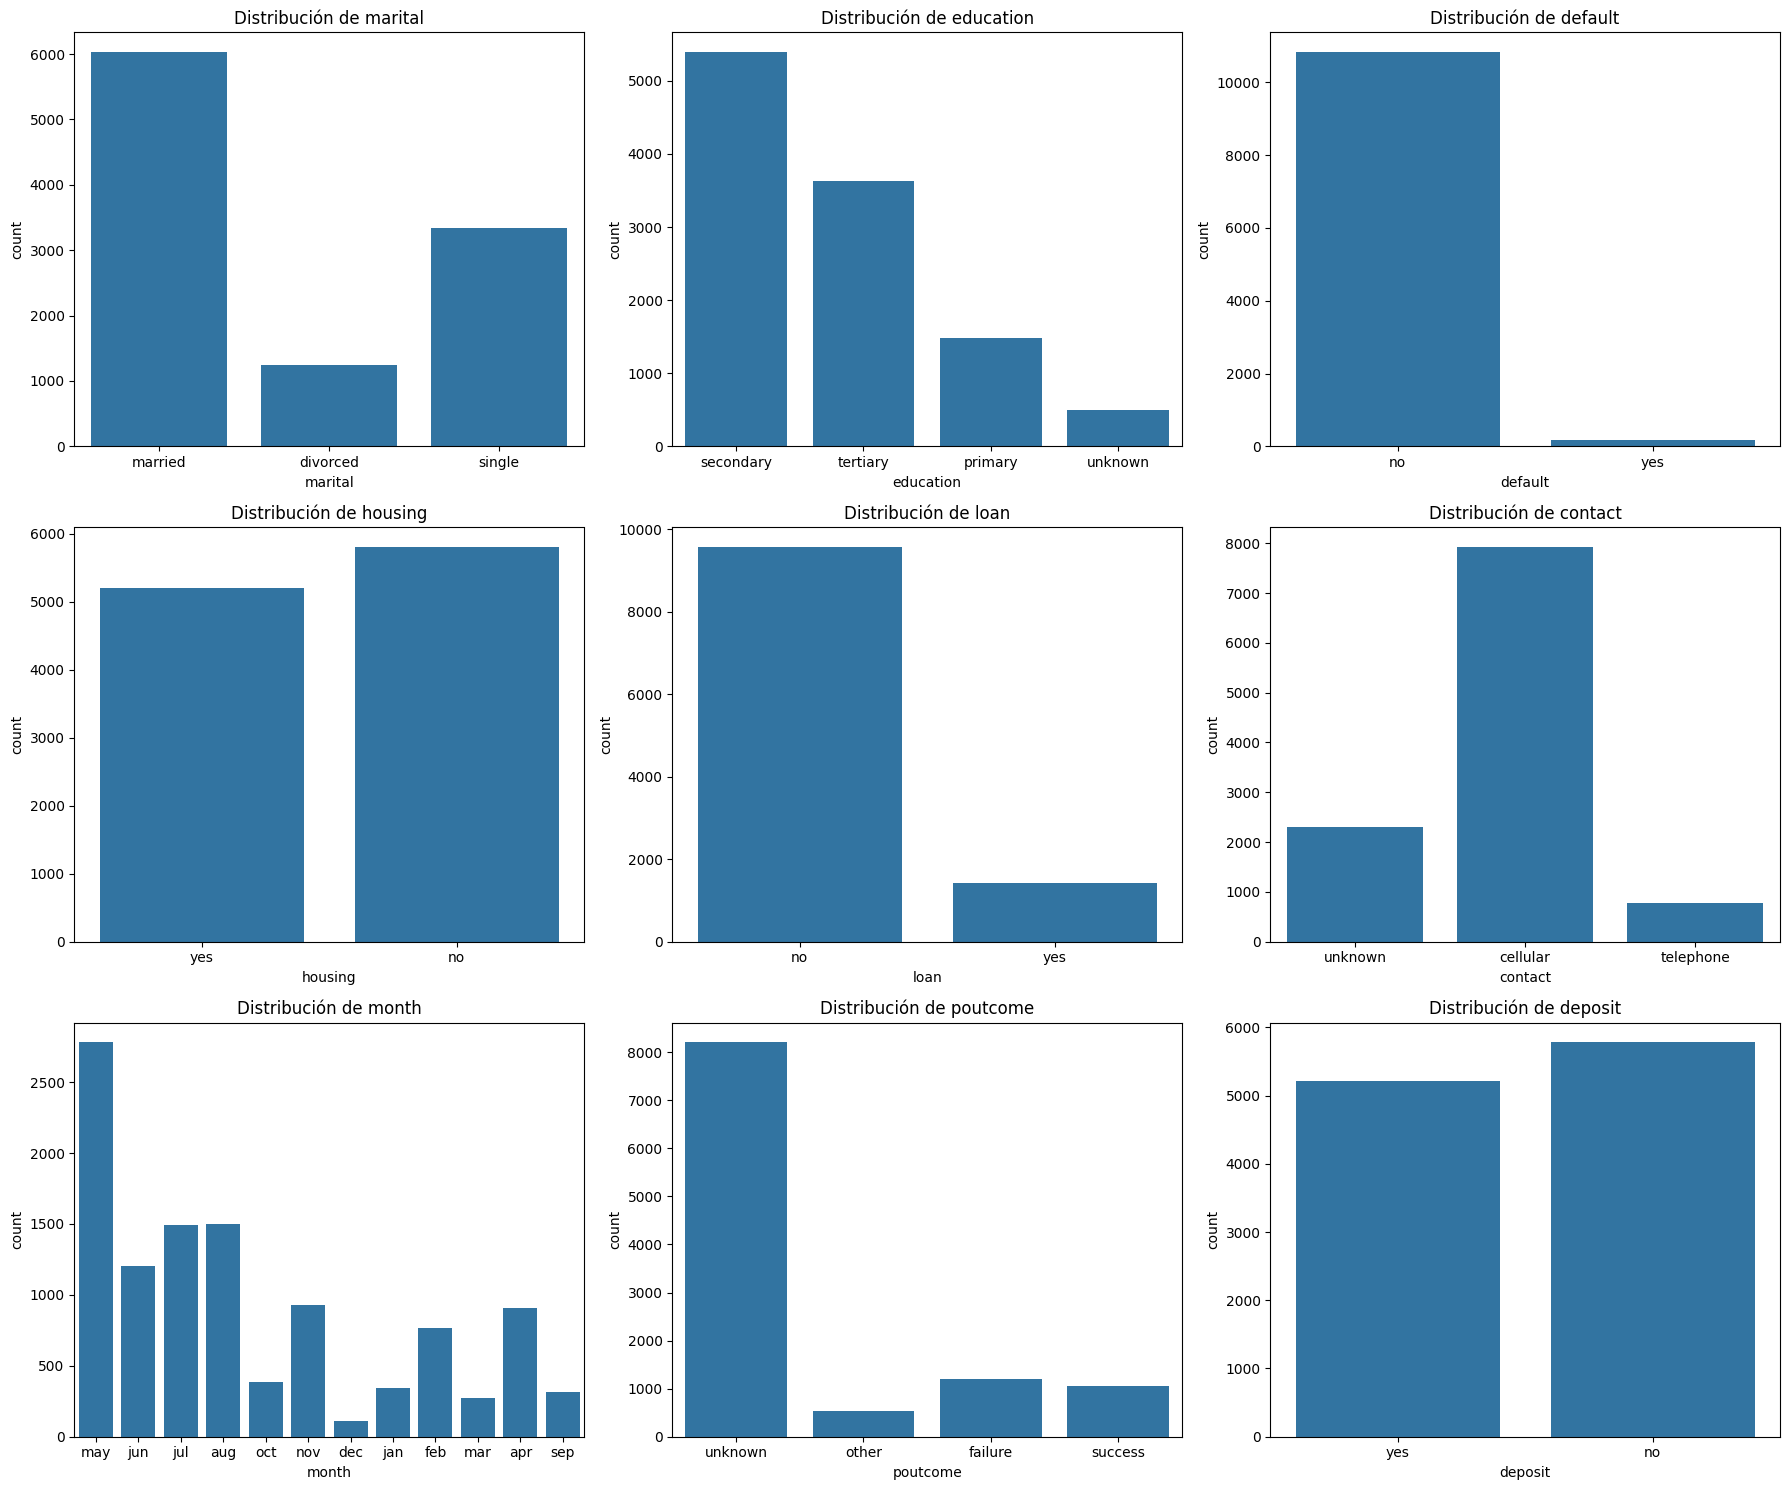

In [36]:
# Creo una lista con los nombres de las variables categóricas
df_categorical = df.select_dtypes(include=['object']).columns

# Eliminamos Job, que visualizaremos aparte ya que su cardinalidad es elevada
df_categorical = df_categorical.drop('job')

n_cols = 3
n_rows = int(np.ceil(len(df_categorical) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, cat in enumerate(df_categorical):
    sns.countplot(data=df, x=cat, ax=axes[i])
    axes[i].set_title(f"Distribución de {cat}")

plt.tight_layout()

### 3. Análisis Bivariante (y Multivariante)

En este apartado se estudiará la relación entre las variables entre sí y con respecto a la variable objetivo `deposit`.

##### Pdays vs. Deposit

De las personas cuyo contacto es desconocido hay más personas que no contrataron un depósito de las que sí lo hicieron.

Por el contrario, de las personas que sí fueron contactadas la mayoría sí contrataron después un depósito.

Esto demuestra que tiene sentido separar esta información creando nuevas variables en el preprocesado que capturen esta información.

<Axes: xlabel='pdays', ylabel='count'>

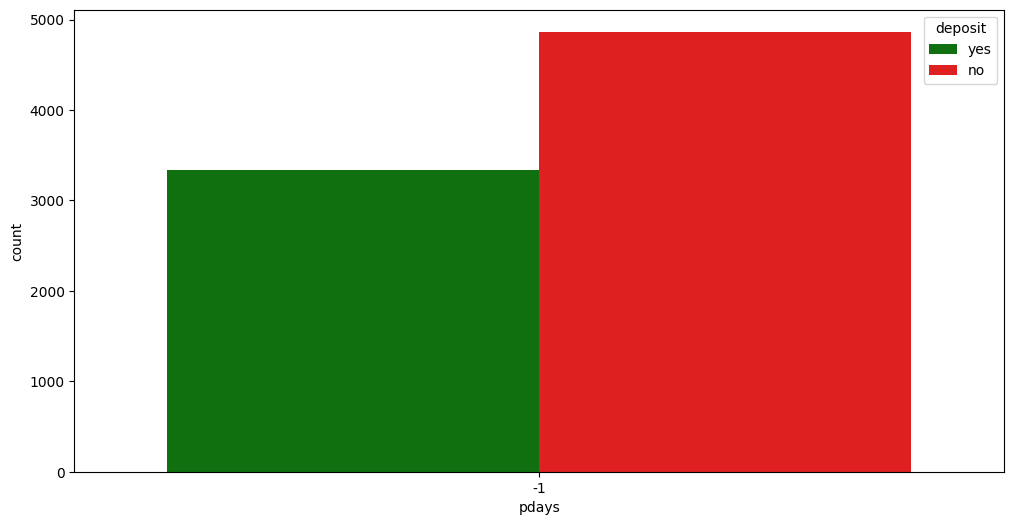

In [37]:
# Visualizamos si contrataron o no un depósito las personas cuyo contacto fue desconocido
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df[df['pdays'] == -1],
    x='pdays',
    hue='deposit',
    palette={'yes': 'green', 'no': 'red'}
)

<Axes: xlabel='pdays', ylabel='Count'>

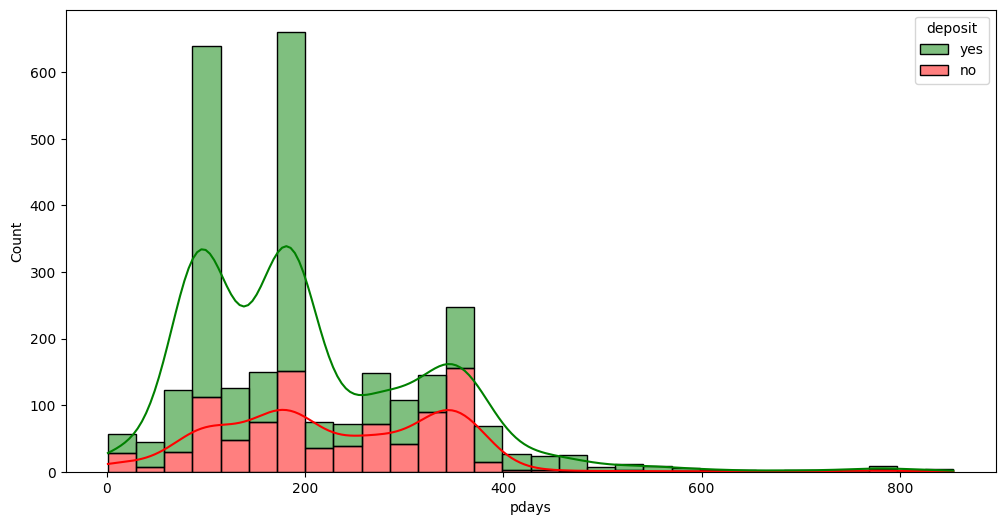

In [38]:
# Visualizamos si contrataron o no un depósito las personas cuyo contacto es conocido

plt.figure(figsize=(12, 6))
sns.histplot(
    data=df[df['pdays'] != -1],
    x='pdays',
    bins=30,
    kde=True,
    hue="deposit",
    multiple='stack',
    palette={'yes': 'green', 'no': 'red'}
)

#### Relación entre Variables Numéricas

En el siguiente gráfico se visualizan *scatterplots* entre todas las combinaciones de las variables numéricas y para la combinación entre una variable consigo misma se representa su distribución en función de si la variable objetivo es *yes* o *no*.

En esta visualización de dos dimensiones parece haber una ligera separación entre las clases al visualizar:

+ **duration vs. age**

+ **duration vs. balance**

+ **duration vs. day**

+ **pdays vs. age**

+ **pdays vs. day**

+ **pdays vs. duration**

También, las distribuciones de **duration** con respecto a **deposit** parecen separse ligeramente.

Aún así, no existe una tupla de variables numéricas que de manera muy clara separe perfectamente las clases de la variable objetivo. Sin embargo, en dimensiones superiores es posible que los datos estén ordenados de alguna manera que no se puede capturar a través de proyecciones en dos dimensiones.


<Figure size 1200x600 with 0 Axes>

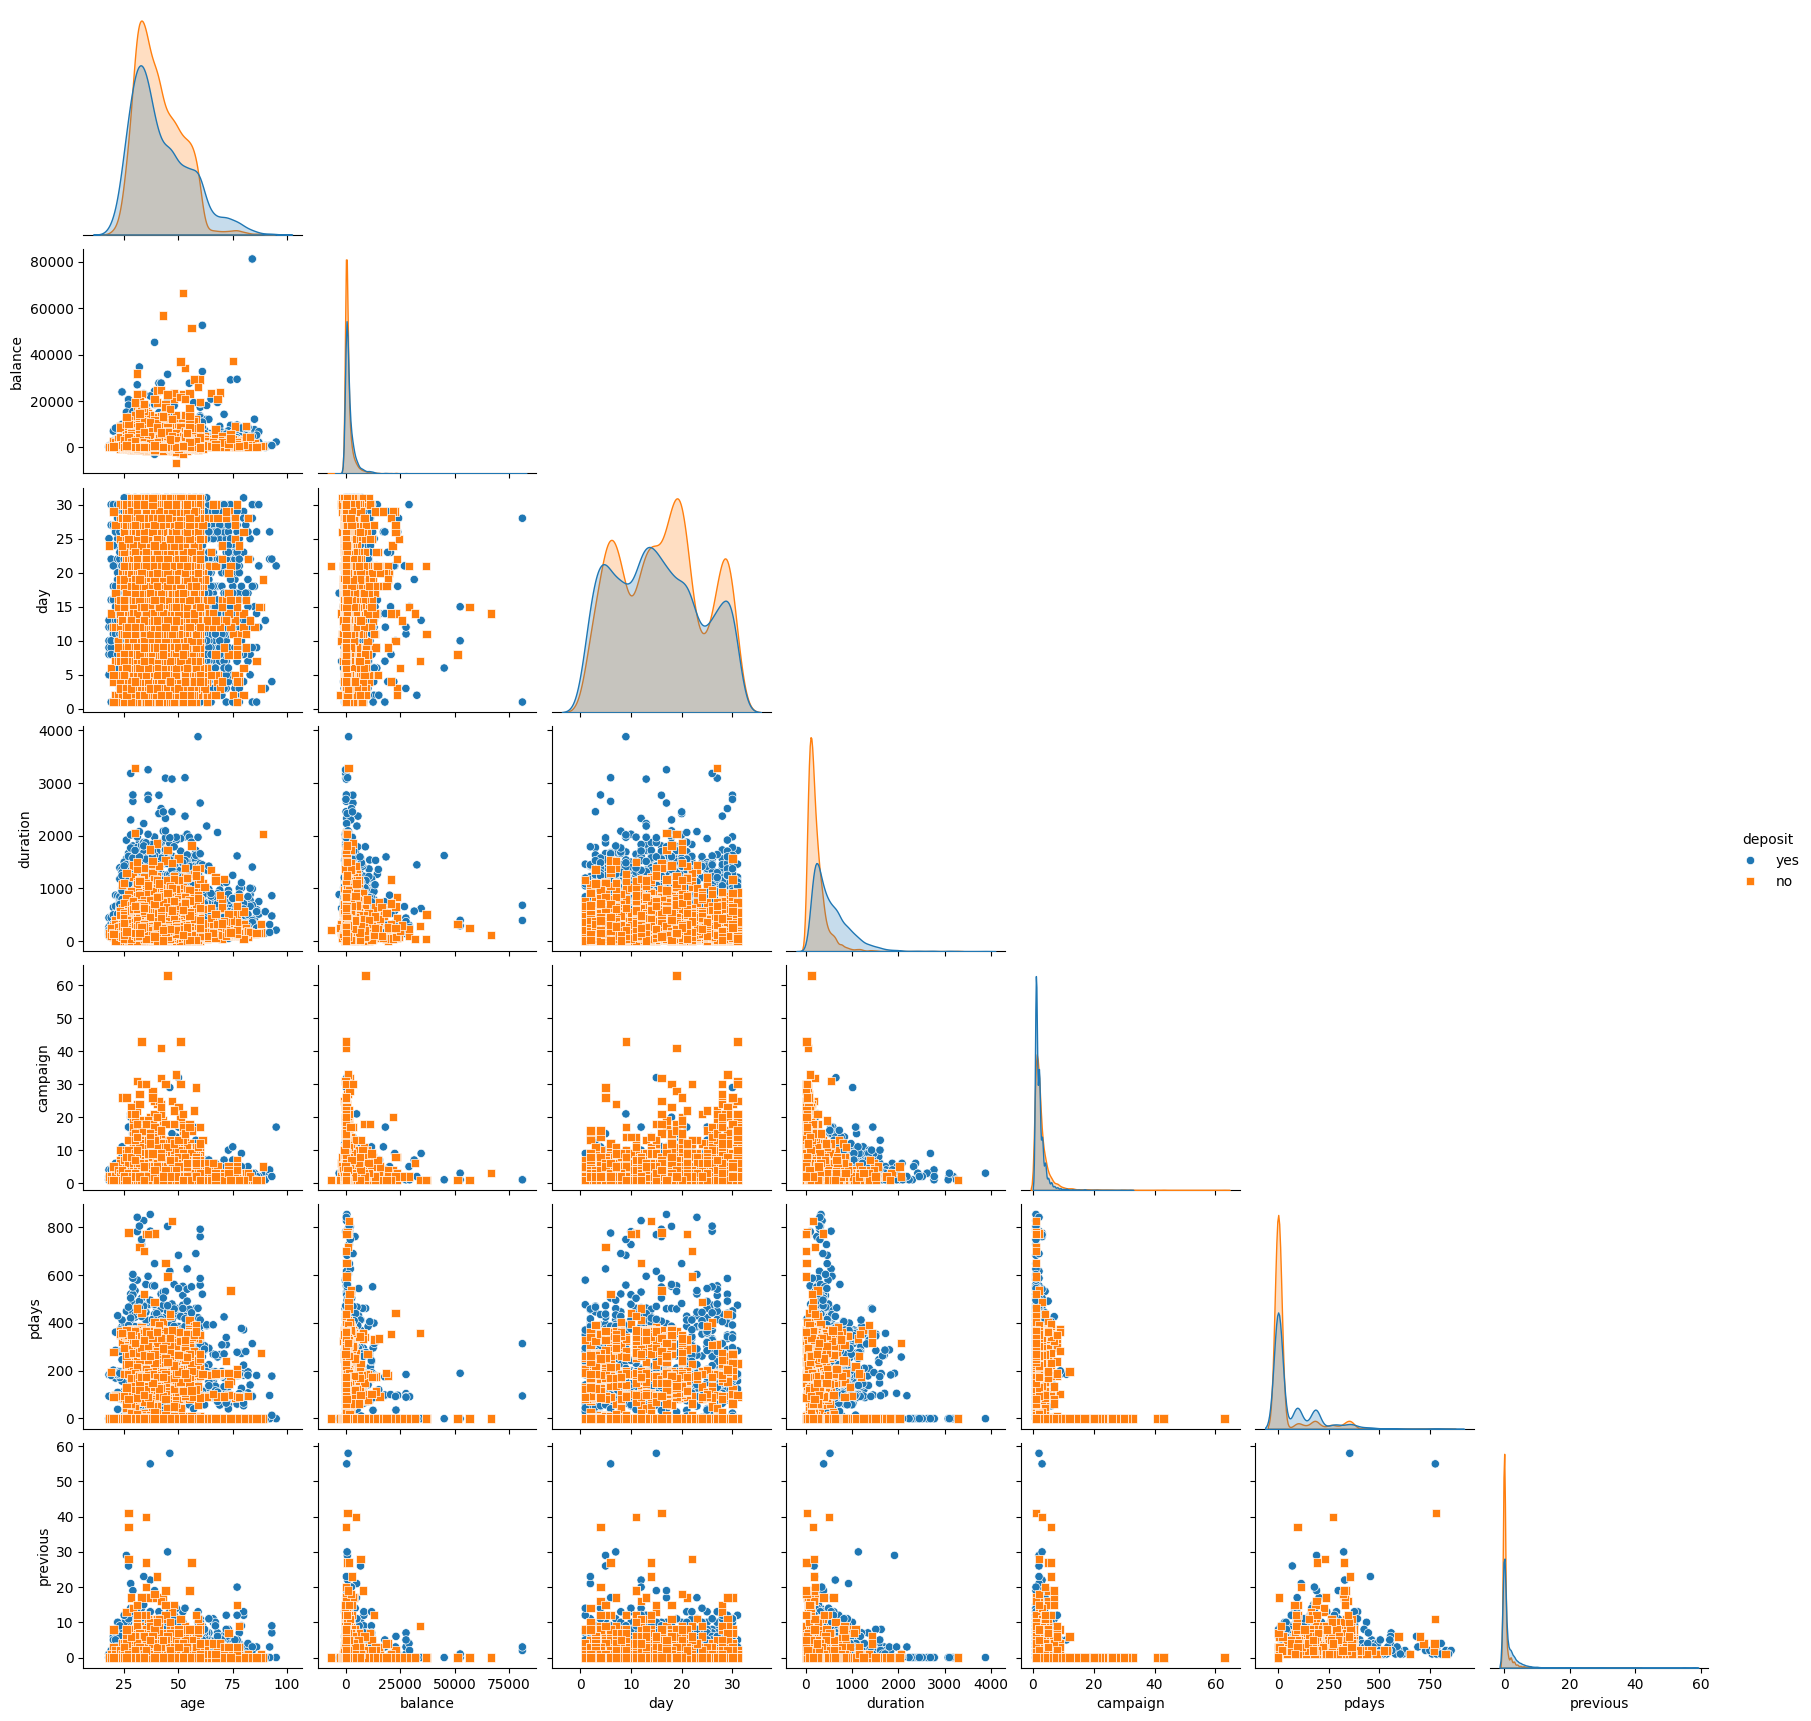

In [39]:
plt.figure(figsize=(12, 6))
sns.pairplot(
    df,
    hue='deposit',
    markers=["o", "s"],
    corner="yes"
)

Como se puede observar en la siguiente matriz de correlación no existen correlaciones fuertes mayores a 0.8 o 0.85 que nos informen de un potencial problema de multicolinealidad. La correlación más fuerte es entre **previous** y **pdays** que es de 0.51, es decir, una correlación lineal débil.

Text(0.5, 1.0, 'Matriz de Correlación Variables Numéricas')

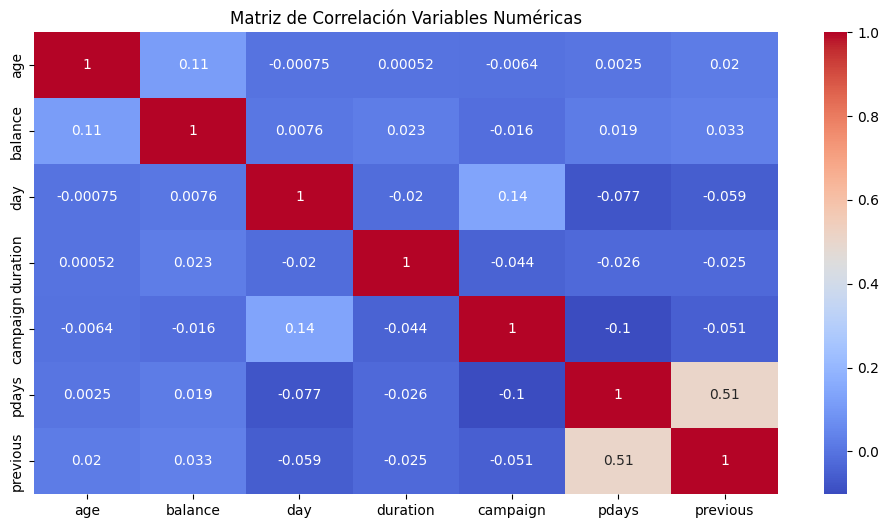

In [40]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title("Matriz de Correlación Variables Numéricas")

#### Relación entre Variables Categóricas respecto a la Variable Objetivo

Algunas observaciones que podemos extraer de la siguiente visualización son:

+ De las personas casadas parece que hay más que no contrataron un depósito de las que sí lo hicieron

+ De las personas que terminaron sus estudios en 'primary' o 'secondary' hay más personas que no contrataron un depósito de las que sí lo hicieron, al contrario que los que terminaron sus estudios en 'tertiary'.

+ De las personas que tienen una hipoteca hay más personas que no contrataron un depósito de las que sí lo hicieron y viceversa con las que no tienen una hipoteca.

+ De las personas que tienen un préstamos hay ligeramente más personas que no contrataron un depósito de las que sí lo hicieron.

+ De las personas que fueron contactadas por última vez en mayo hay más personas que no contrataron de las que sí lo hicieron esto solo ha sido al revés con personas contactadas en Febrero, Marzo, Abril, Septiembre, Octubre y Diciembre.

+ De las personas que fueron alcanzadas exitosamente por la última campaña la gran mayoría han contratado un depósito.

Finalmente, cabe señalar que en la categoría desconocido de **contact** y **poutcome** hay más personas que no contrataron un depósito de las que sí lo hicieron, como esta ausencia de información parece ser potencialmente útil para separar las clases, en el preprocesado se puede probar a crear las variables 'isContactUnknown' y 'isPoutcomeUnknown'.

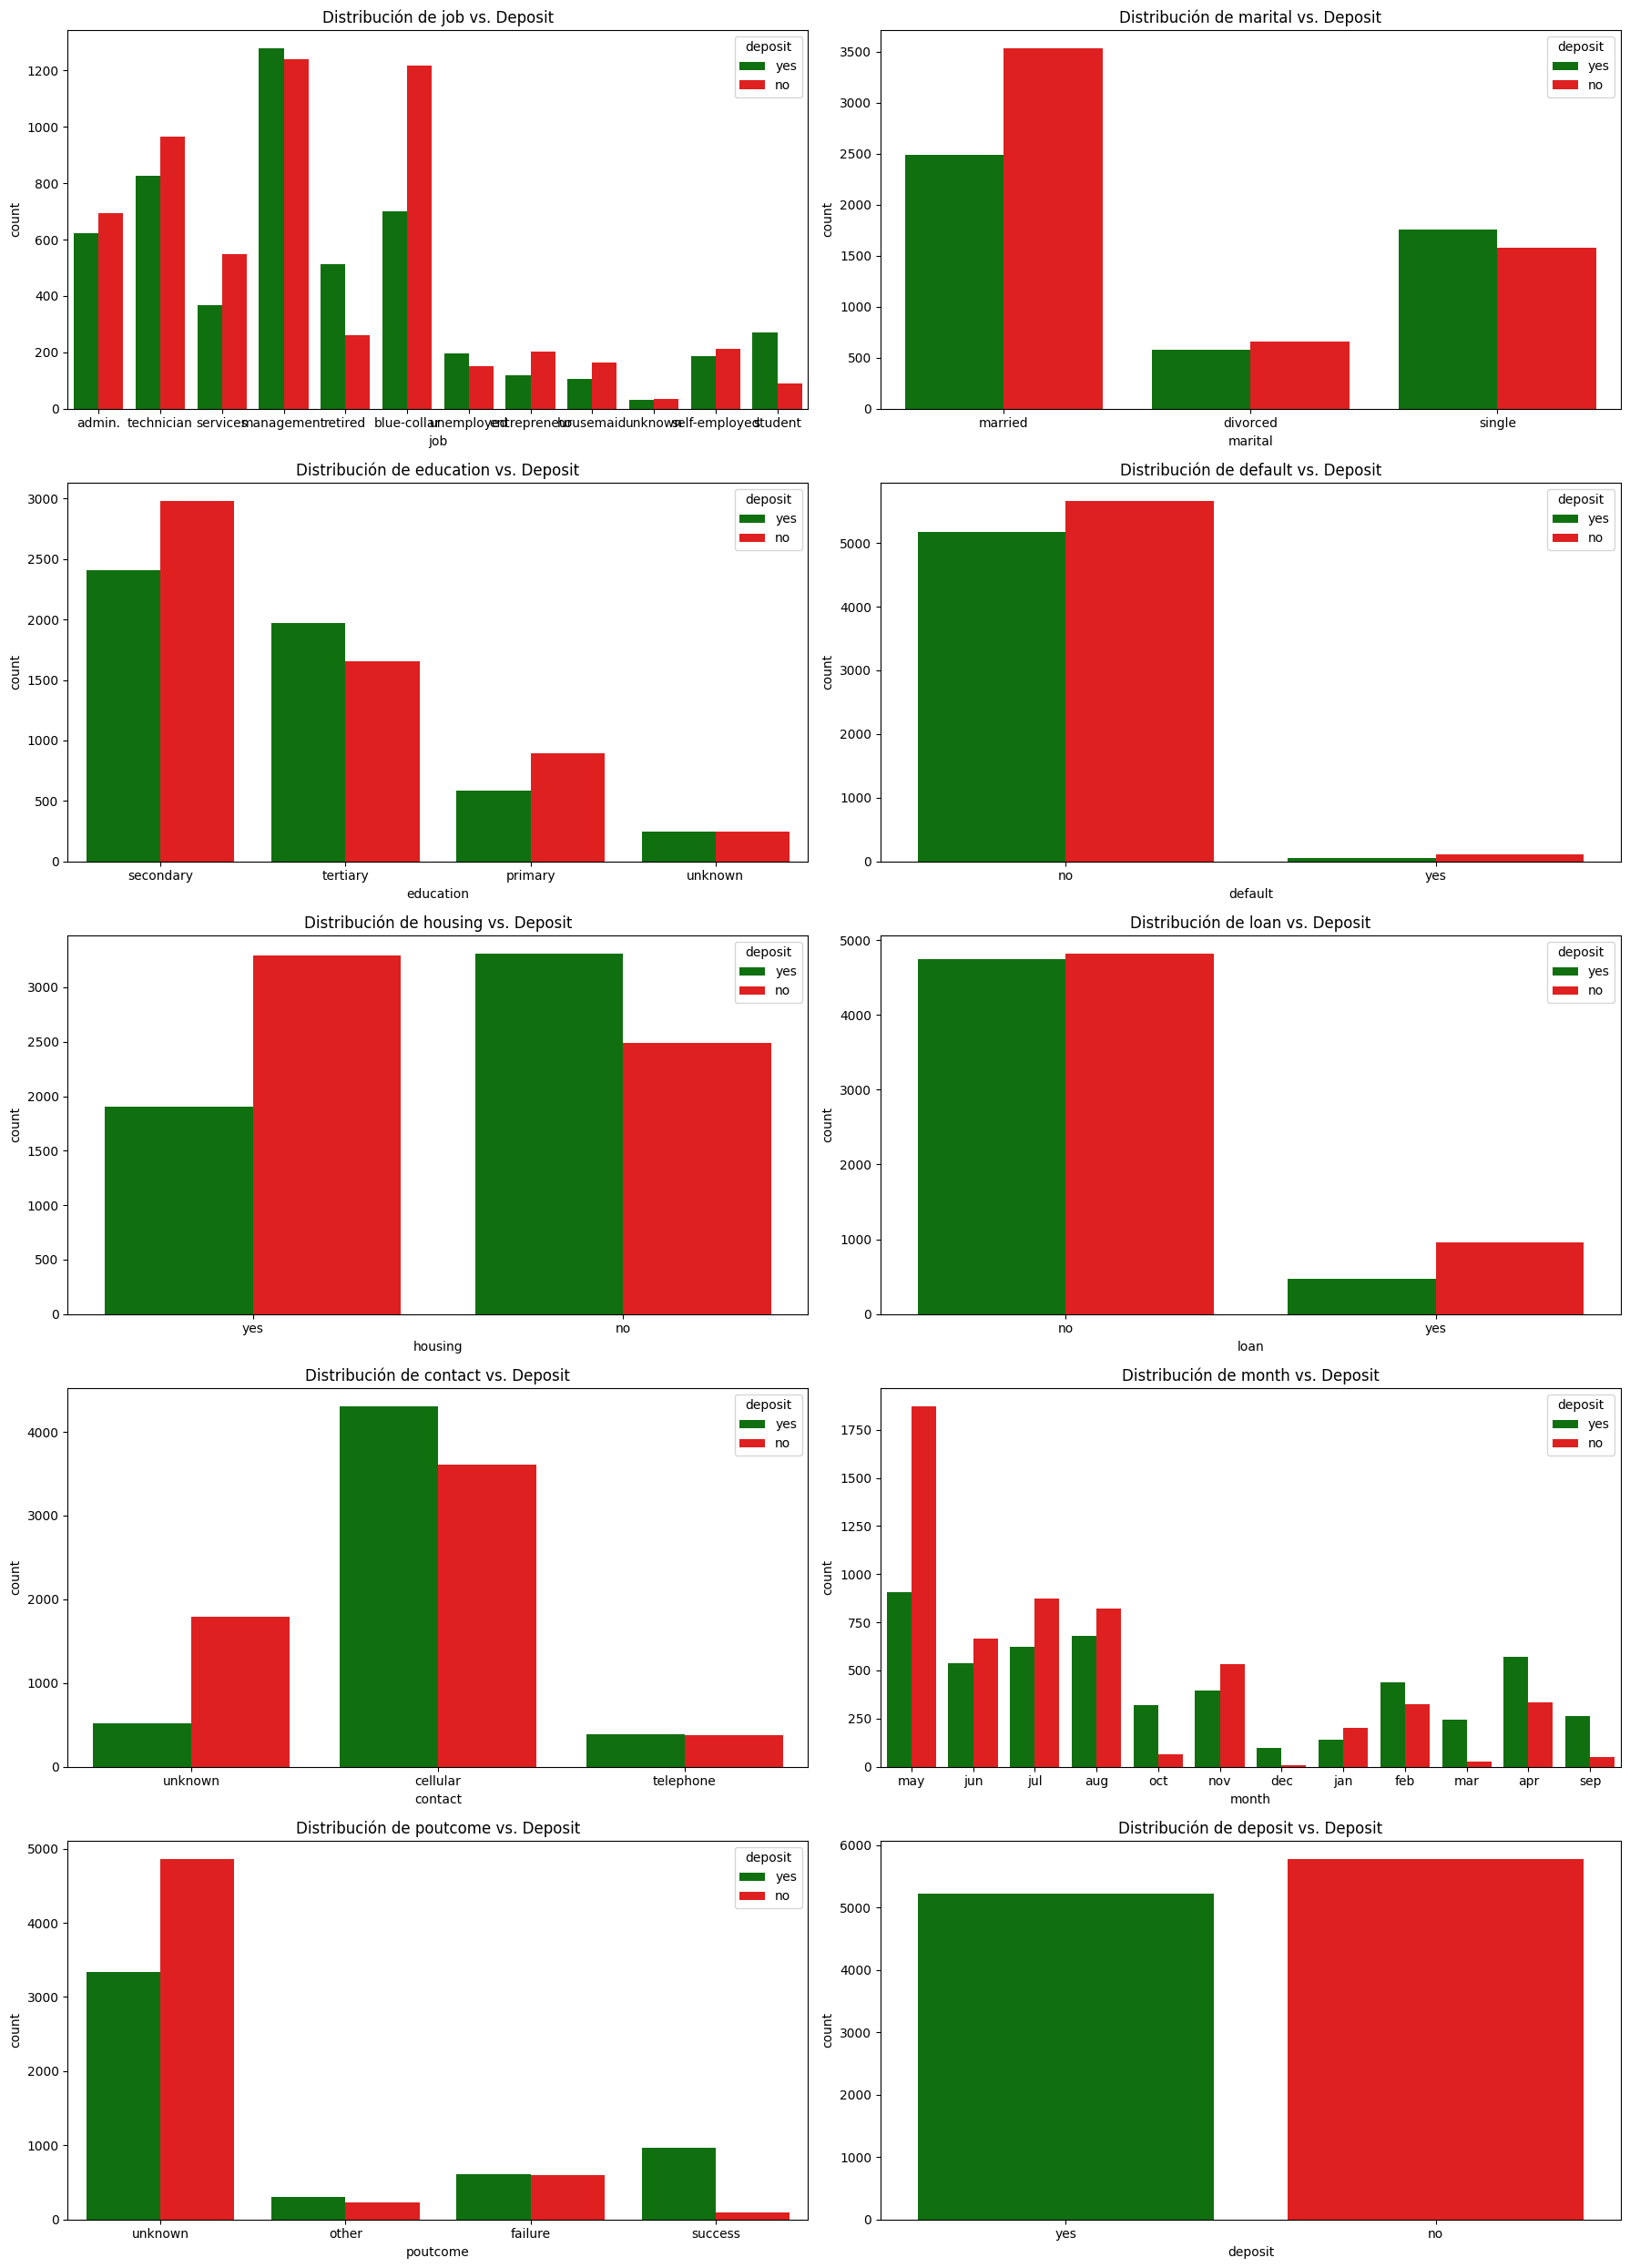

In [41]:
categorical_cols = df.select_dtypes(include="object").columns

n_cols = 2
n_rows = int(np.ceil(len(df_categorical)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, cat in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=cat,
        ax=axes[i],
        hue='deposit',
        palette={'yes': 'green', 'no': 'red'}
    )
    axes[i].set_title(f"Distribución de {cat} vs. Deposit")

plt.tight_layout()

#### Relación entre Variables Numéricas y Categóricas

+ **pdays vs. contact**: De las personas cuyo medio de contacto ha sido desconocido, aquellas que han sido contactados en menos de 400 días han contratado un depósito y aquellas que en muchos más días no lo han efectuado.

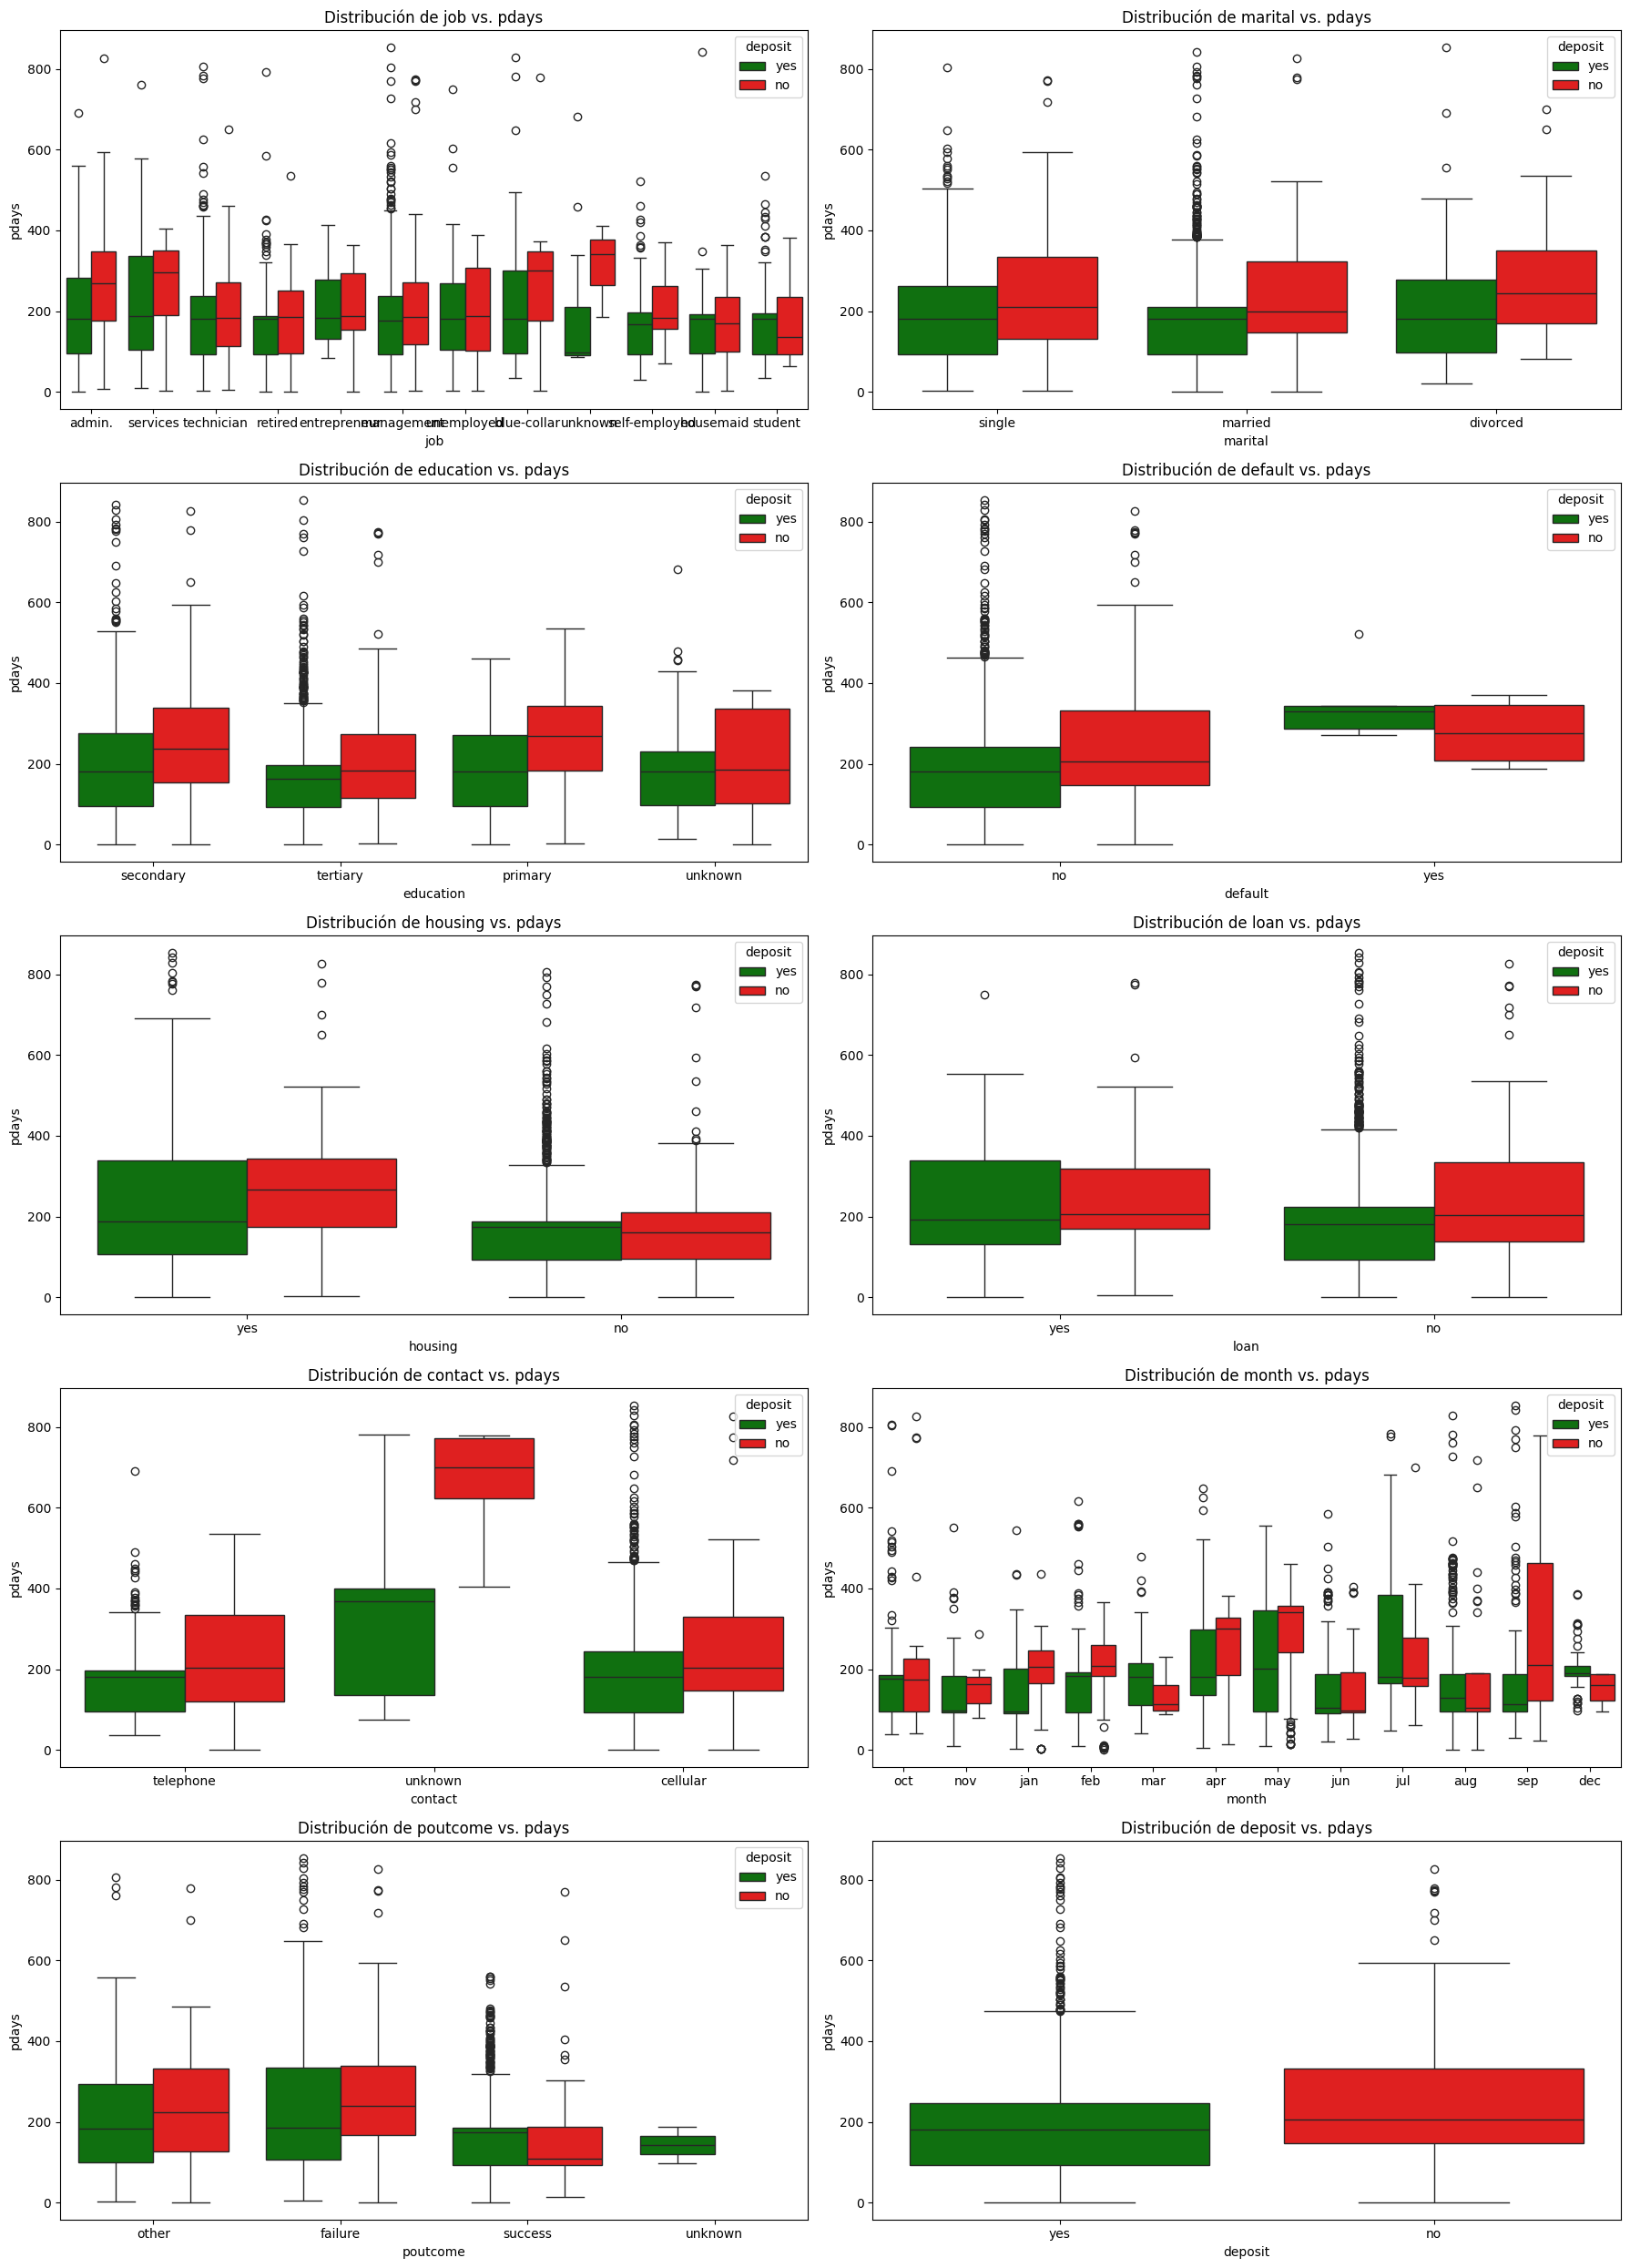

In [42]:
num_col = "pdays"
cat_cols = df.select_dtypes(include="object").columns
cat_cols = cat_cols.drop("deposit")

n_cols = 2
n_rows = int(np.ceil(len(df_categorical)/n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, cat in enumerate(categorical_cols):
    sns.boxplot(
        data=df[df['pdays'] != -1],
        x=cat,
        y=num_col,
        ax=axes[i],
        hue='deposit',
        palette={'yes': 'green', 'no': 'red'}
    )
    axes[i].set_title(f"Distribución de {cat} vs. {num_col}")

plt.tight_layout()